In [3]:
from pynq import Overlay
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import threading
import time

ol   = Overlay('/home/xilinx/angus.bit')
regs = ol.top_0

regs.write(0x04, 192)
regs.write(0x20, 1)
regs.write(0x00, 0x03)
print('Overlay loaded')

Overlay loaded


In [13]:
STATES = {0:'UNSYNC', 1:'FIRST_GAP', 2:'SYNC_CRANK', 3:'SYNC_FULL'}

w_kp    = widgets.BoundedIntText(value=256,  min=0, max=65535, description='KP:')
w_ki    = widgets.BoundedIntText(value=16,   min=0, max=65535, description='KI:')
w_maxc  = widgets.BoundedIntText(value=1024, min=0, max=65535, description='Max corr:')
w_phase = widgets.BoundedIntText(value=1717, min=0, max=7199,  description='Phase ang:')
w_tol   = widgets.BoundedIntText(value=300,  min=0, max=7199,  description='Phase tol:')
w_write = widgets.Button(description='Write all', button_style='primary')

w_state  = widgets.Label(value='sync: ---')
w_rpm    = widgets.Label(value='RPM: ---')
w_ph_err = widgets.Label(value='phase err: ---')
w_corr   = widgets.Label(value='correction: ---')
w_losses = widgets.Label(value='sync losses: ---')
w_ab     = widgets.Label(value='ab_count: ---')
w_gap    = widgets.Label(value='gap_per: ---')
w_cam    = widgets.Label(value='cam_angle: ---')

err_history = []
running = False

def sign32(v):
    return v - 0x100000000 if v > 0x7FFFFFFF else v

def write_all(b):
    regs.write(0x08, w_kp.value)
    regs.write(0x0C, w_ki.value)
    regs.write(0x10, w_maxc.value)
    regs.write(0x14, w_phase.value)
    regs.write(0x18, w_tol.value)
    print(f'Written: KP={w_kp.value} KI={w_ki.value} MAXC={w_maxc.value} PHASE={w_phase.value} TOL={w_tol.value}')

w_write.on_click(write_all)

def poll():
    while running:
        try:
            status  = regs.read(0x24)
            tp      = regs.read(0x48)
            pe      = sign32(regs.read(0x54))
            co      = sign32(regs.read(0x58))
            sl      = regs.read(0x28)
            ab      = regs.read(0x44)
            gap     = regs.read(0x4C)
            cam     = regs.read(0x5C)
            rpm     = round(60_000_000 / (tp/100) / 60) if tp > 0 else 0
            ph_deg  = pe / 4_294_967_296 * 360
            w_state.value  = f'sync: {STATES.get(status & 0x7, "?")}'  
            w_rpm.value    = f'RPM: {rpm}'
            w_ph_err.value = f'phase err: {ph_deg:.3f} deg'
            w_corr.value   = f'correction: {co}'
            w_losses.value = f'sync losses: {sl}'
            w_ab.value     = f'ab_count: {ab}'
            w_gap.value    = f'gap_per: {gap} ({gap/100000:.1f}ms)'
            w_cam.value    = f'cam_angle: {cam} ({cam/10:.1f} deg)'
            err_history.append(ph_deg)
            if len(err_history) > 120:
                err_history.pop(0)
        except Exception as e:
            w_state.value = f'error: {e}'
        time.sleep(0.1)

params_box = widgets.VBox([w_kp, w_ki, w_maxc, w_phase, w_tol, w_write])
status_box = widgets.VBox([w_state, w_rpm, w_ph_err, w_corr, w_losses, w_ab, w_gap, w_cam])
display(widgets.HBox([params_box, status_box]))

running = True
t = threading.Thread(target=poll, daemon=True)
t.start()
print('Polling started')

Polling started
Written: KP=256 KI=16 MAXC=20000 PHASE=1717 TOL=300
Written: KP=256 KI=16 MAXC=65535 PHASE=1717 TOL=300
Written: KP=1000 KI=16 MAXC=65535 PHASE=1717 TOL=300
Written: KP=200 KI=16 MAXC=65535 PHASE=1717 TOL=300
Written: KP=1000 KI=16 MAXC=65535 PHASE=1717 TOL=300
Written: KP=1000 KI=100 MAXC=65535 PHASE=1717 TOL=300
Written: KP=10000 KI=100 MAXC=65535 PHASE=1717 TOL=300
Written: KP=250 KI=20 MAXC=65535 PHASE=1717 TOL=300
Written: KP=250 KI=20 MAXC=65535 PHASE=50 TOL=300
Written: KP=250 KI=20 MAXC=65535 PHASE=1717 TOL=300
Written: KP=250 KI=20 MAXC=65535 PHASE=1717 TOL=300
Written: KP=250 KI=20 MAXC=65535 PHASE=50 TOL=300
Written: KP=250 KI=20 MAXC=65535 PHASE=1717 TOL=300
Written: KP=250 KI=20 MAXC=65535 PHASE=1717 TOL=150


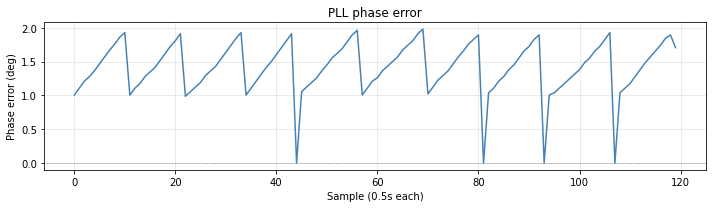

In [26]:
# Run repeatedly to refresh the phase error plot
plt.figure(figsize=(10, 3))
plt.plot(err_history, color='steelblue', linewidth=1.5)
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.ylabel('Phase error (deg)')
plt.xlabel('Sample (0.5s each)')
plt.title('PLL phase error')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
running = False
print('Polling stopped')

Polling stopped
